In [5]:
%load_ext autoreload
%autoreload 2

In [6]:
import pandas as pd
from src.final_model import (
    evaluate_regression_model,
    fit_final_model,
    get_largest_errors,
    make_prediction_results,
    plot_actual_vs_predicted,
    plot_residual_distribution,
    plot_residuals,
    predict_final_model,
)
from sklearn.model_selection import train_test_split

In [7]:
df = pd.read_csv('../data/raw/diamonds.csv', index_col=0)

X = df.drop(columns=['price'])
y = df['price']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [8]:
final_model = fit_final_model(
    X_train=X_train,
    y_train=y_train,
)

In [9]:
y_pred = predict_final_model(
    model=final_model,
    X_test=X_test,
)

In [11]:
final_metrics = evaluate_regression_model(
    y_true=y_test,
    y_pred=y_pred,
)

final_metrics

{'rmse': np.float64(534.4027577555332),
 'mae': 268.8350476227127,
 'r2': 0.982035005653656}

In [12]:
prediction_results = make_prediction_results(
    X_test=X_test,
    y_test=y_test,
    y_pred=y_pred,
)

prediction_results.head()

,carat,cut,color,clarity,depth,table,x,y,z,actual_price,predicted_price,residual,absolute_error
1389,0.24,Ideal,G,VVS1,62.1,56.0,3.97,4.00,2.47,559,562.271588,-3.271588,3.271588
50053,0.58,Very Good,F,VVS2,60.0,57.0,5.44,5.42,3.26,2201,2303.426768,-102.426768,102.426768
41646,0.40,Ideal,E,VVS2,62.1,55.0,4.76,4.74,2.95,1238,1260.730471,-22.730471,22.730471
42378,0.43,Premium,E,VVS2,60.8,57.0,4.92,4.89,2.98,1304,1332.201668,-28.201668,28.201668
17245,1.55,Ideal,E,SI2,62.3,55.0,7.44,7.37,4.61,6901,9124.296006,-2223.296006,2223.296006


(<Figure size 700x700 with 1 Axes>,
 <Axes: title={'center': 'Actual vs predicted price'}, xlabel='Actual price', ylabel='Predicted price'>)

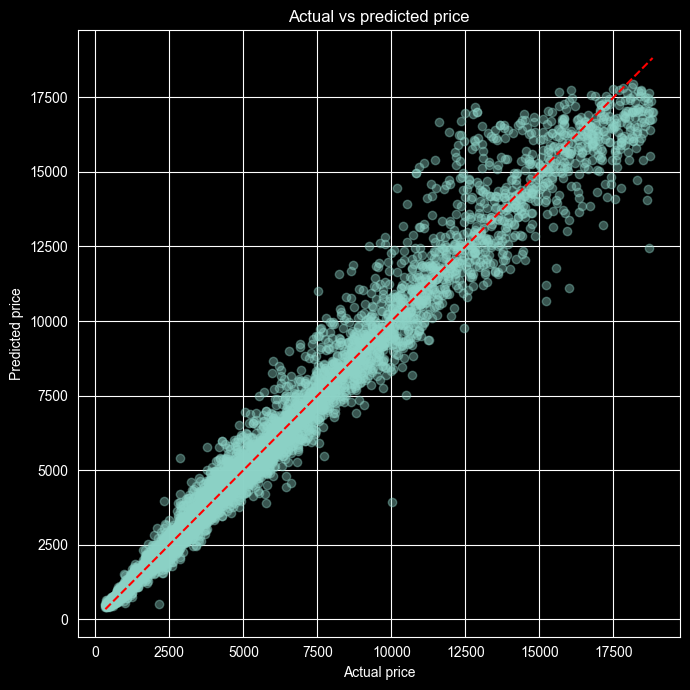

In [13]:
plot_actual_vs_predicted(
    y_true=y_test,
    y_pred=y_pred,
)

(<Figure size 1000x500 with 1 Axes>,
 <Axes: title={'center': 'Residuals vs predicted price'}, xlabel='Predicted price', ylabel='Residual'>)

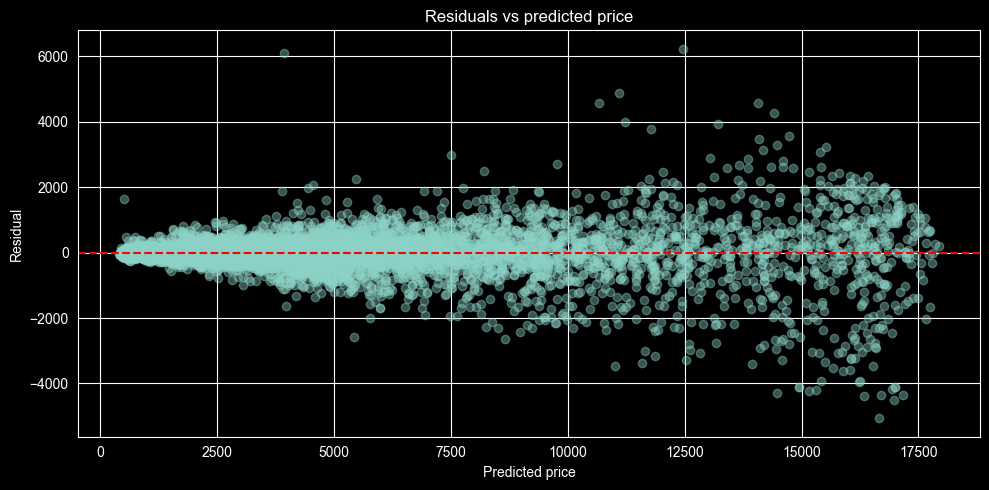

In [14]:
plot_residuals(
    y_true=y_test,
    y_pred=y_pred,
)

(<Figure size 1000x500 with 1 Axes>,
 <Axes: title={'center': 'Residual distribution'}, xlabel='Residual', ylabel='Count'>)

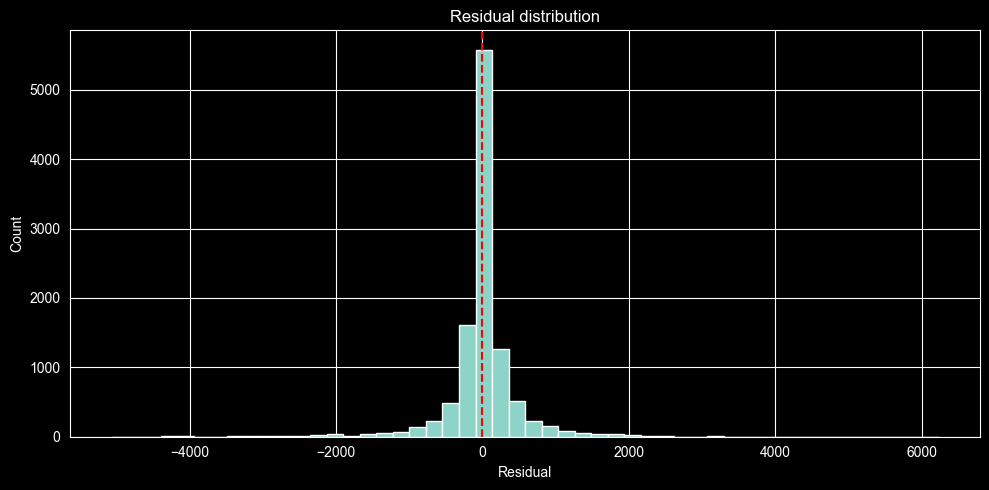

In [15]:
plot_residual_distribution(
    y_true=y_test,
    y_pred=y_pred,
)

In [16]:
get_largest_errors(
    prediction_results=prediction_results,
    top_n=10,
)

,carat,cut,color,clarity,depth,table,x,y,z,actual_price,predicted_price,residual,absolute_error
27674,1.50,Very Good,G,VS2,60.7,59.0,7.31,7.38,4.46,18691,12461.114797,6229.885203,6229.885203
21936,1.01,Fair,D,SI2,64.6,58.0,6.25,6.20,4.02,10011,3920.167859,6090.832141,6090.832141
23588,2.01,Ideal,G,SI2,61.5,55.0,8.15,8.11,5.00,11602,16666.433454,-5064.433454,5064.433454
26445,4.00,Very Good,I,I1,63.3,58.0,10.01,9.94,6.31,15984,11102.065412,4881.934588,4881.934588
27662,2.09,Very Good,F,SI2,63.4,55.0,8.18,8.11,5.16,18640,14061.512001,4578.487999,4578.487999
25999,4.01,Premium,I,I1,61.0,61.0,10.14,10.10,6.17,15223,10660.279184,4562.720816,4562.720816
24259,2.40,Ideal,J,SI1,62.0,57.0,8.53,8.47,5.27,12468,16985.896044,-4517.896044,4517.896044
23862,2.01,Good,I,VS2,64.3,60.0,7.91,7.86,5.07,11954,16336.177324,-4382.177324,4382.177324
24166,2.04,Premium,H,SI1,62.2,60.0,8.07,8.00,5.00,12341,16704.899651,-4363.899651,4363.899651
24540,2.01,Ideal,G,SI1,61.6,57.0,8.08,8.00,4.95,12829,17171.498963,-4342.498963,4342.498963
